<a href="https://colab.research.google.com/github/ShailenB/POC/blob/main/YuluStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import ttest_ind
import statsmodels.api as sm
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


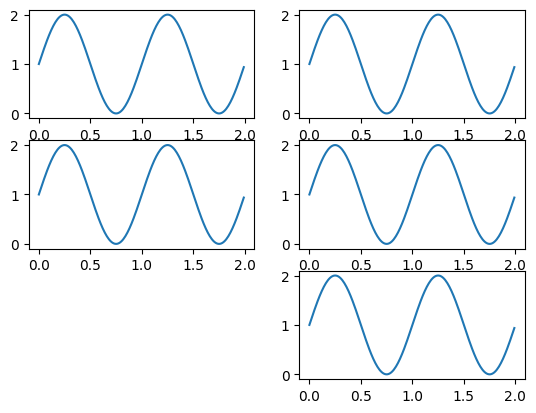

In [ ]:
x = np.arange(0.0, 2.0, 0.01)
y = 1 + np.sin(2 * np.pi * x)
plot1 = plt.subplot2grid((3, 2), (0, 0), colspan=1)
plot2 = plt.subplot2grid((3, 2), (1, 0), colspan=1)
plot3 = plt.subplot2grid((3, 2), (0, 1), colspan=1)
plot4 = plt.subplot2grid((3, 2), (1, 1), colspan=1)
plot5 = plt.subplot2grid((3, 2), (2, 1), colspan=2)
plot1.plot(x, y)
plot2.plot(x, y)
plot3.plot(x, y)
plot4.plot(x, y)
plot5.plot(x, y)
plt.show()

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/bike_sharing.csv')

In [ ]:
print("number of rows= ",df.shape[0],"\nnumber of columns= ",df.shape[1])

number of rows=  10886 
number of columns=  12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
np.mean(df.casual), np.mean(df.registered), np.mean(df['count'])

(36.02195480433584, 155.5521771082124, 191.57413191254824)

In [ ]:
np.sum(df.casual), np.sum(df.registered), np.sum(df['count'])

(392135, 1693341, 2085476)

Looking at the data, and column profiling, it's obvious that columns 'season', 'holiday', 'working_day', 'weather', qualify to be retyped as 'category'.

In [ ]:
#'season', 'holiday', 'working_day', 'weather'
df['season']=df['season'].astype('category')
df['holiday']=df['holiday'].astype('category')
df['workingday']=df['workingday'].astype('category')
df['weather']=df['weather'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   datetime    10886 non-null  object  
 1   season      10886 non-null  category
 2   holiday     10886 non-null  category
 3   workingday  10886 non-null  category
 4   weather     10886 non-null  category
 5   temp        10886 non-null  float64 
 6   atemp       10886 non-null  float64 
 7   humidity    10886 non-null  int64   
 8   windspeed   10886 non-null  float64 
 9   casual      10886 non-null  int64   
 10  registered  10886 non-null  int64   
 11  count       10886 non-null  int64   
dtypes: category(4), float64(3), int64(4), object(1)
memory usage: 723.7+ KB


The datetime needs to be retyped as datetime, instead of an object.

In [ ]:
df['datetime']=pd.to_datetime(df['datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: category(4), datetime64[ns](1), float64(3), int64(4)
memory usage: 723.7 KB


In [ ]:
df.describe(exclude=['object', 'datetime64[ns]', 'category'])

,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


Correlation analysis to identify non correlated parameters to dig in further.

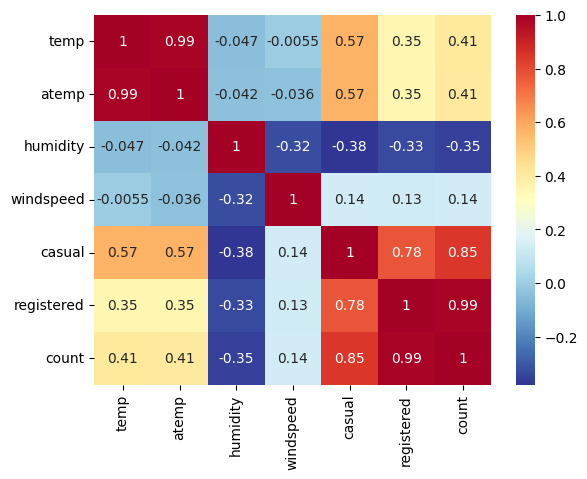

In [ ]:
crr=df.corr(method='spearman', numeric_only=True)
sns.heatmap(data=crr, annot=True, cmap='RdYlBu_r')
plt.show()

- 'temp', 'atemp', are highly correlated, hence one of them can be dropped.  
- 'count' is sum of 'registered', and 'casual', hence are highly correlated. Since we are interested in investigating the bicycle hire for the two classes of customers, we can conviniently drop  'count', and focus on 'casual', and 'registered'.

In [ ]:
df_nu=df.drop(['temp'], axis=1)

In [ ]:
df_nu.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

- Outlier detection:

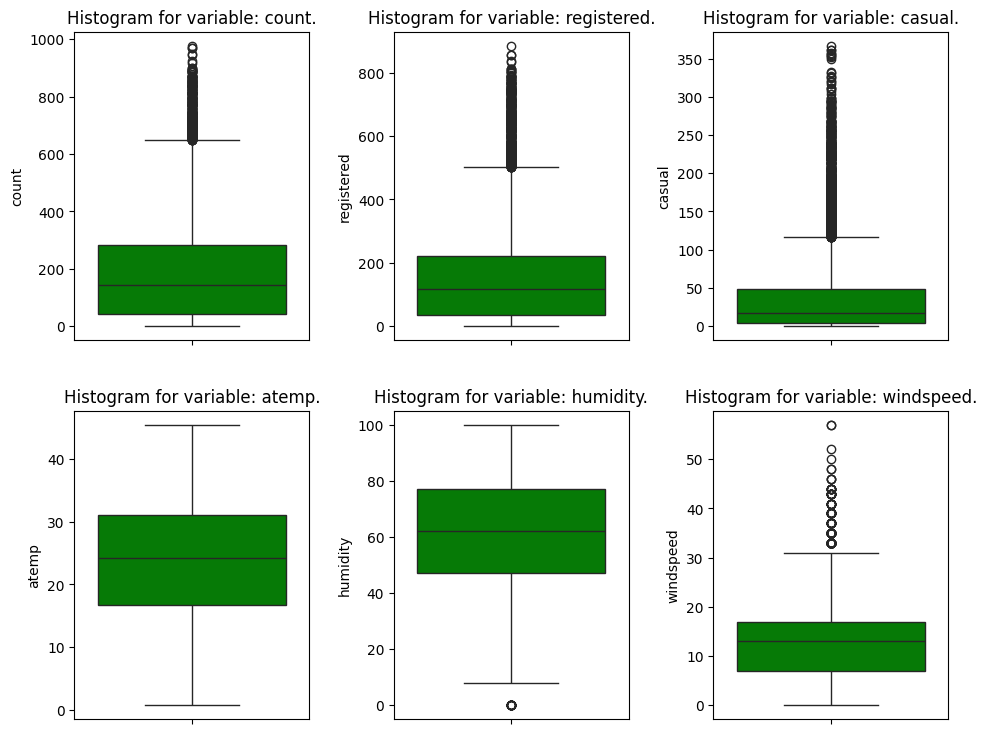

In [ ]:
lst=['count','registered','casual','atemp','humidity', 'windspeed' ] # numeric variables
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(10, 8), squeeze=True )
plt.tight_layout(pad=3)
index = 0
for row in range(2):
    for col in range(3):
        sns.boxplot(y=df_nu[lst[index]], ax=axis[row, col],saturation=0.9, color='green')
        axis[row, col].set_title('Histogram for variable: '+lst[index]+'.')
        index += 1
plt.show()

- 'windspeed', 'count', 'registered', and 'casual' have outliers and looks like they are skewed too.
- Checking the variables for normality, using pg.normality() :
 ‘shapiro’ (default) performs the Shapiro-Wilk test on data.

In [ ]:
pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.9/198.9 kB 1.8 MB/s eta 0:00:00


In [ ]:
import pingouin as pg
res=pg.normality(df_nu[lst])
res

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10886.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
count,0.878366,5.369838e-68,False
registered,0.856278,1.972967e-71,False
casual,0.705635,3.544796e-87,False
atemp,0.981530,3.220898e-35,False
humidity,0.982259,1.222029e-34,False
windspeed,0.958734,7.590115e-48,False


- None of these numeric columns have normal distribution.
- Assessing skewness.

In [ ]:
for i in range(len(lst)):
  print('skewness of ', lst[i], ': ',stats.skew(df_nu[lst[i]]))

skewness of  count :  1.241895058803035
skewness of  registered :  1.5245944734221468
skewness of  casual :  2.495404491505502
skewness of  atemp :  -0.10254538108264065
skewness of  humidity :  -0.0863232869219358
skewness of  windspeed :  0.5886853963635482


- 'casual' is heavily skewed.
- Skewness for 'atemp', and 'humidity' is very small, and can be ignored.
- 'windspeed' is little skewed negatively.
- 'count is skewed positive.
- Applying boxcox transformation; 'count' leads to 'cnt', and 'windspeed' to 'wnspd'.  
- 'cnt' to be used instead of 'count' for further statistical procedures.
- 'wnspd' to be used instead of 'windspeed' for further statistical procedures.

In [ ]:
df_nu['cnt'], alphc=stats.boxcox(df_nu['count'])

In [ ]:
df_nu['rgd'], alphac=stats.boxcox(df_nu['registered']+0.5)

In [ ]:
df_nu['csl'], alphcs=stats.boxcox(df_nu['casual']+0.5)

In [ ]:
df_nu['wspd'], alphaw=stats.boxcox(df_nu['windspeed']+.5)

In [ ]:
lst

['count', 'registered', 'casual', 'atemp', 'humidity', 'windspeed']

In [ ]:
lst1=['cnt', 'rgd', 'csl', 'wspd']
for i in range(len(lst1)):
  print('skewness of ', lst1[i], ': ',stats.skew(df_nu[lst1[i]]))

skewness of  cnt :  -0.15393121207576468
skewness of  rgd :  -0.1279036037280082
skewness of  csl :  -0.058365465684053125
skewness of  wspd :  -0.18154549095281927


In [ ]:
df_nu.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'cnt', 'rgd',
       'csl', 'wspd'],
      dtype='object')

- Skewness of all 3 parameters reduced to acceptable levels.
- Dataset now ready for analyses

Univariate analyses:
- Histograms for numerical columns

In [ ]:
lst1

['cnt', 'rgd', 'csl', 'wspd']

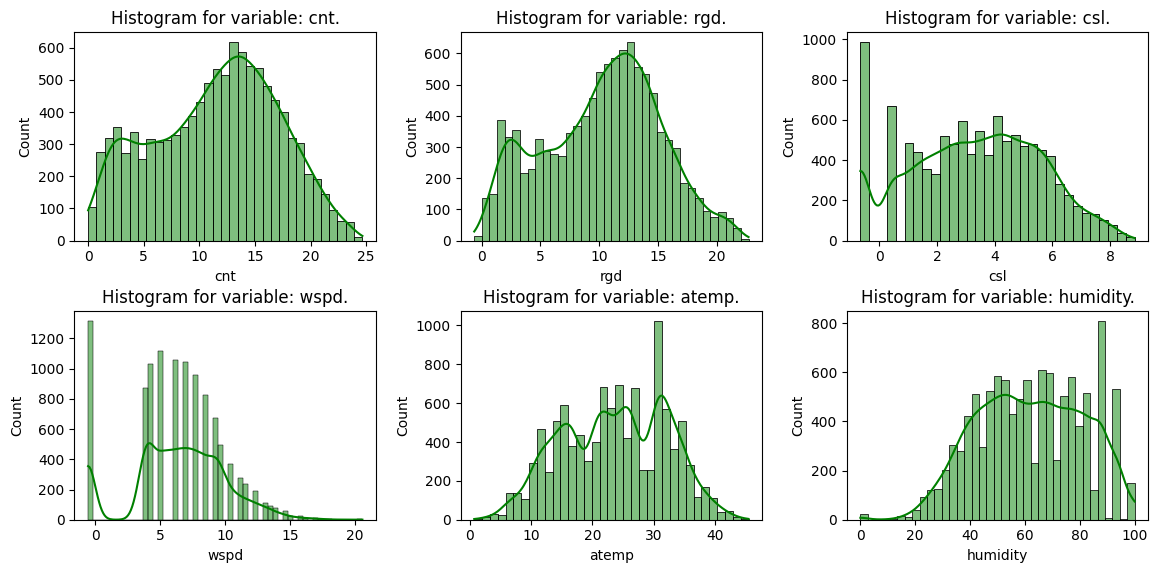

In [ ]:
lst2=[ 'cnt', 'rgd', 'csl', 'wspd','atemp','humidity'] # numeric variables windspeed, and count replaced by their transformed ones
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), squeeze=True )
fig.tight_layout(pad=3)
index = 0
for row in range(2):
    for col in range(3):
        sns.histplot(df_nu[lst2[index]], ax=axis[row, col], kde=True, color='green')
        axis[row, col].set_title('Histogram for variable: '+lst2[index]+'.')
        index += 1
plt.show()

- Countplots for categorical columns

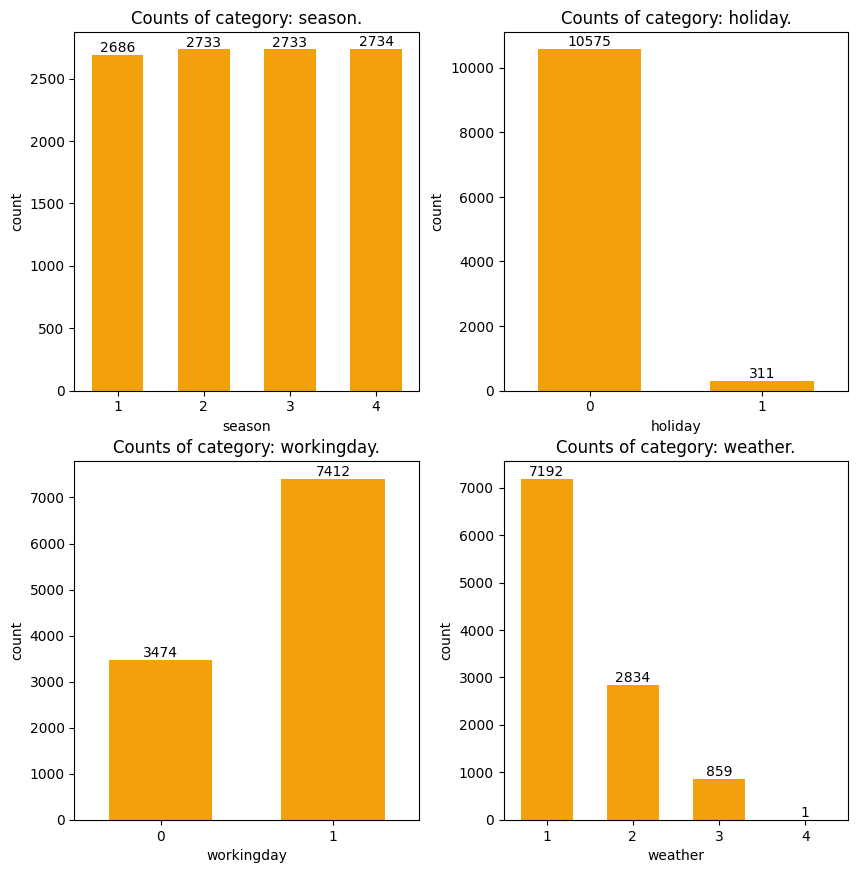

In [ ]:
ct_c= ['season', 'holiday', 'workingday', 'weather']  #categorical columns
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(9, 9), squeeze=True)
fig.tight_layout(pad=3)
index = 0
for row in range(2):
    for col in range(2):
        sns.countplot(x=ct_c[index], data=df_nu,ax=axis[row, col], width=0.6, saturation=.9, color='orange').bar_label(axis[row, col].containers[0])
        axis[row, col].set_title('Counts of category: '+ct_c[index]+'.')
        index += 1
plt.show()

In [ ]:
lst3=[ 'count', 'registered', 'casual', 'windspeed','atemp','humidity']

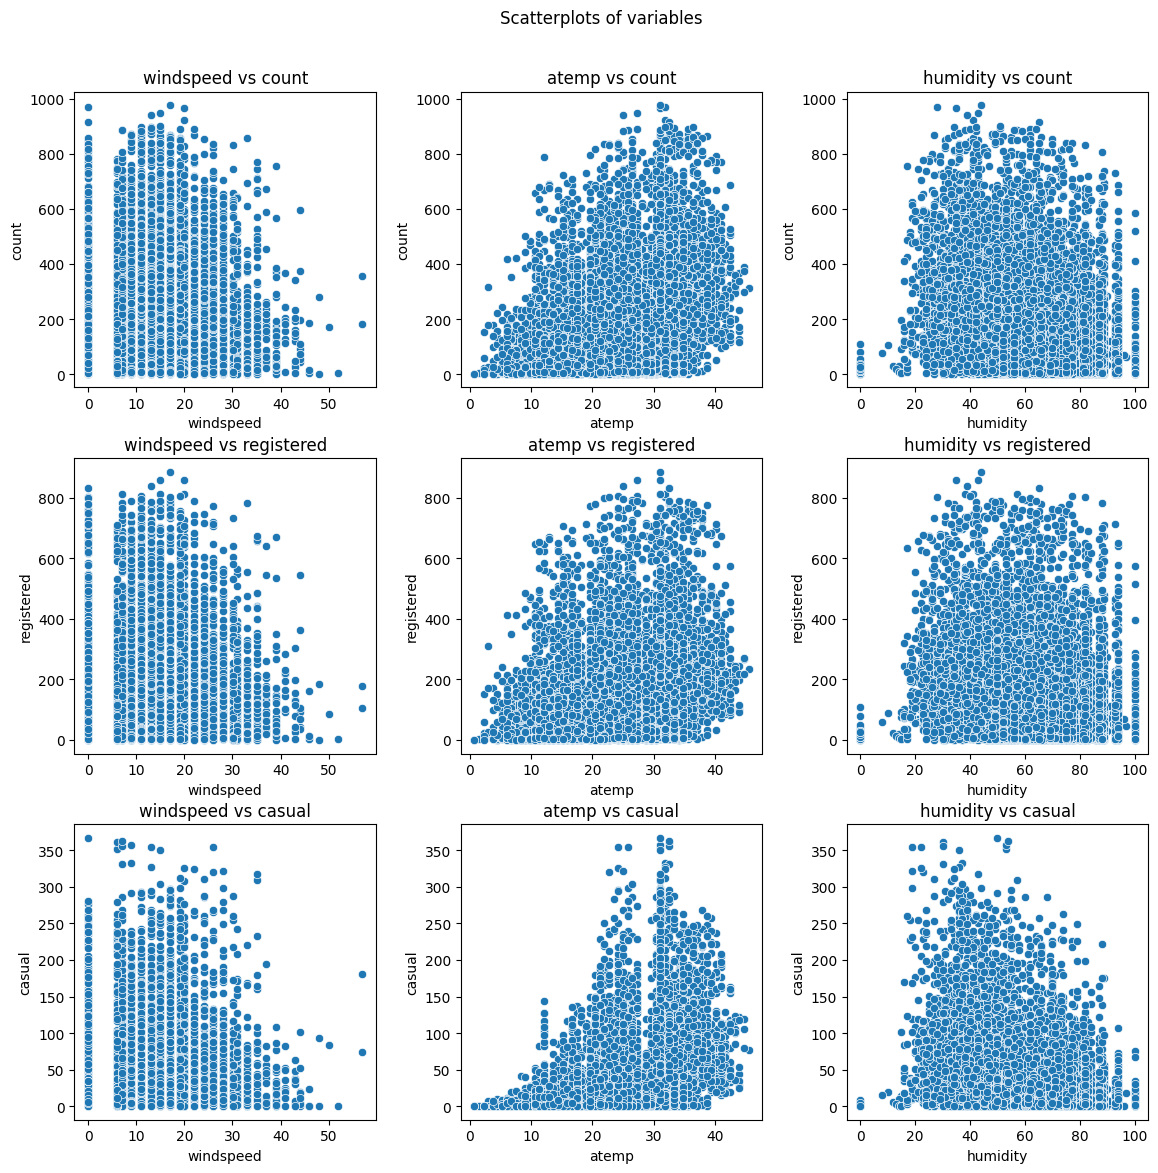

In [ ]:
fig, axis = plt.subplots(nrows=3, ncols=3, figsize=(12, 12), squeeze=True )
fig.suptitle('Scatterplots of variables')
fig.tight_layout(pad=3)
for row in range(3):
    for col in range(3):
      sns.scatterplot(x=lst3[col+3], y=lst3[row], data=df_nu, ax=axis[row, col]).set_title(lst3[col+3]+' vs '+lst3[row])
plt.show()

Bivariate analyses:

In [ ]:
df_n=df_nu.drop(['windspeed', 'count', 'registered', 'casual'], axis=1 )

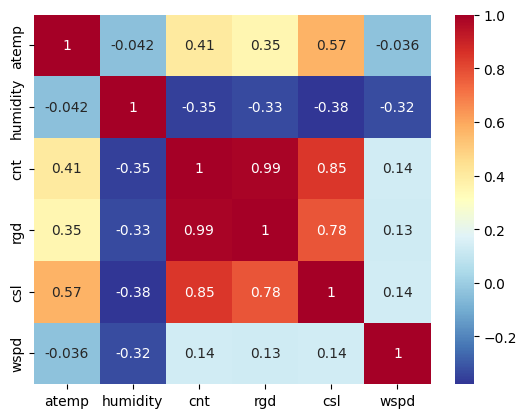

In [ ]:
corr=df_n.corr(method='spearman', numeric_only=True)
sns.heatmap(data=corr, annot=True, cmap='RdYlBu_r')
plt.show()

'windspeed', 'count' are transformed to 'wspd' and 'cnt' respectively, hence, 'windspeed', 'count' are dropped.

In [ ]:
df_nu.drop(['casual','count','windspeed', 'registered'], axis=1, inplace=True)

In [ ]:
df_nu.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'cnt', 'rgd',
       'csl', 'wspd'],
      dtype='object')

**Question**: Weather count of bike hires is differ on working day, and non-working day.
- Relevant columns 'workingday', and 'cnt'
- 'workingday' = 1 for working day, = 0 otherwise.

Applying T-test to seek insight:

In [ ]:
df_nu.workingday.value_counts()

,count
workingday,
1,7412
0,3474


Saperating the 'working day', and 'non working' day data for 'cnt'.
- 'workingday'=1 - working day including weekdays
- 'workingday'=0 non working day weekends/ holidays

In [ ]:
df_wd=df_nu[df_nu.workingday==1]
df_nd=df_nu[df_nu.workingday==0]

Check for skewness:

In [ ]:
stats.skew(df_wd['rgd']), stats.skew(df_nd['rgd'])

(-0.13406790967957788, -0.2520272420250651)

In [ ]:
stats.skew(df_wd['csl']), stats.skew(df_nd['csl'])

(-0.2341062436204737, -0.10845232727080215)

In [ ]:
lst1=['rgd', 'csl','cnt']
print('Working day:')
for i in range(len(lst1)):
  if i==0:
    print( pg.normality(df_wd[lst1[i]]))
  else:
    print( pg.normality(df_wd[lst1[i]]).iloc)
print('Non-working day:')
for i in range(len(lst1)):
  print( pg.normality(df_nd[lst1[i]]))

Working day:


NameError: name 'pg' is not defined

In [ ]:
print('Working day:','\n')
for i in range(len(lst1)):
  print(pd.DataFrame(pg.normality(df_wd[lst1[i]])))
  print('skewness: ', stats.skew(df_wd[lst1[i]]))
print('\n','Non-working day: ','\n')
for i in range(len(lst1)):
  print(pd.DataFrame(pg.normality(df_nd[lst1[i]])))
  print('skewness: ', stats.skew(df_nd[lst1[i]]))


Working day: 

            W          pval  normal
rgd  0.976843  5.096403e-33   False
skewness:  -0.13406790967957788
            W          pval  normal
csl  0.957261  4.573707e-42   False
skewness:  -0.2341062436204737
            W          pval  normal
cnt  0.975514  8.526863e-34   False
skewness:  -0.1800087694415957

 Non-working day:  

            W          pval  normal
rgd  0.971995  1.513525e-25   False
skewness:  -0.2520272420250651
            W          pval  normal
csl  0.970926  5.442602e-26   False
skewness:  -0.10845232727080215
           W          pval  normal
cnt  0.97604  9.665596e-24   False
skewness:  -0.08728213112470194


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)


Skewness is low.

Checking for normality

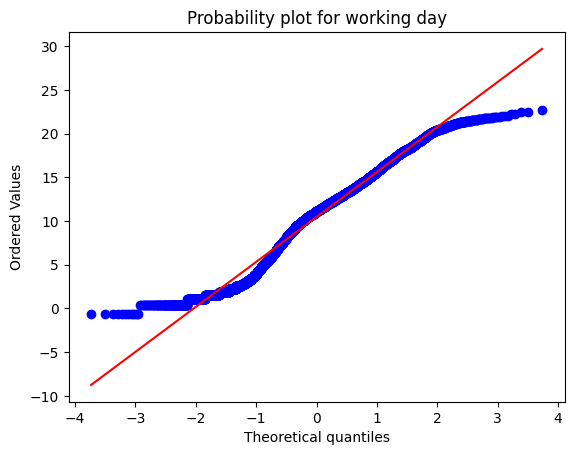

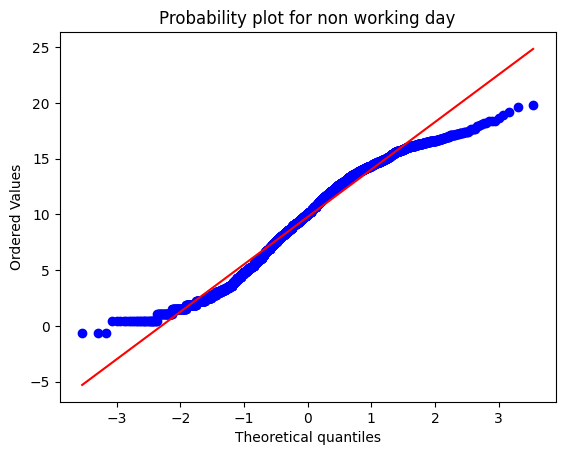

In [ ]:
stats.probplot(df_wd['rgd'], dist="norm", plot=plt)
plt.title('Probability plot for working day')
plt.show()
stats.probplot(df_nd['rgd'], dist="norm", plot=plt)
plt.title('Probability plot for non working day')
plt.show()

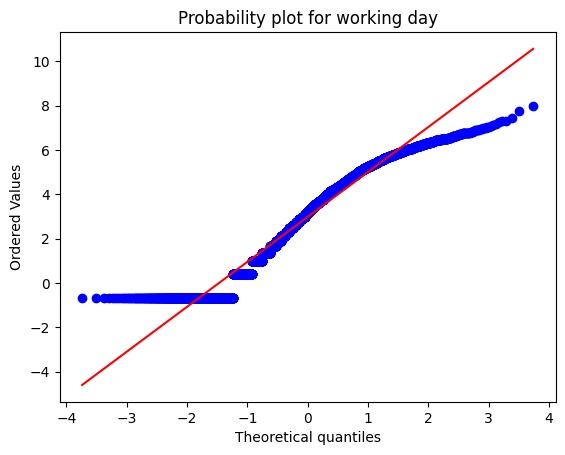

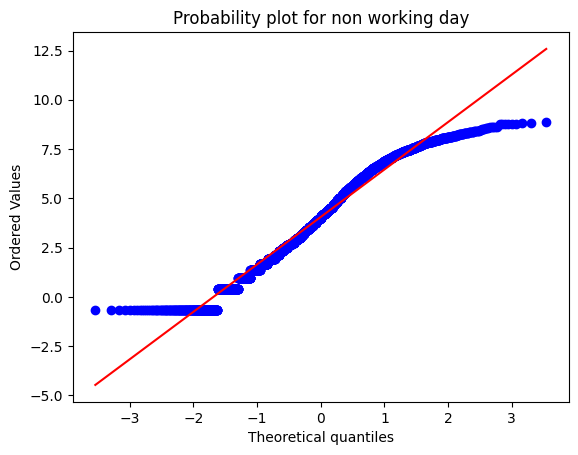

In [ ]:
stats.probplot(df_wd['csl'], dist="norm", plot=plt)
plt.title('Probability plot for working day')
plt.show()
stats.probplot(df_nd['csl'], dist="norm", plot=plt)
plt.title('Probability plot for non working day')
plt.show()

In [ ]:
pg.normality(df_wd['rgd']), pg.normality(df_nd['rgd'])

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)


(            W          pval  normal
 rgd  0.976843  5.096403e-33   False,
             W          pval  normal
 rgd  0.971995  1.513525e-25   False)

In [ ]:
pg.normality(df_wd['csl']), pg.normality(df_nd['csl'])

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)


(            W          pval  normal
 csl  0.957261  4.573707e-42   False,
             W          pval  normal
 csl  0.970926  5.442602e-26   False)

**Is there a significant difference in count of bike rentals on a working day against a non working day?**

*Hypothesis test:*

The two populations being compared are:
* number of bike rented on working days-df_wd['cnt']
* number of bike rented on non-working days-df_nd['cnt']

Although these are not pure normal distributed, we choose the independent t test; carrying out a 2 tailed test.
* Ho: There is no significant difference in bike hiring on non-working days as compared to working days.
* H1: There is significant difference in bike hiring on non-working days as compared to working days.

Level of significance: 0.05

In [ ]:
lsta=['registered customers', 'casual customers','overall customers']

In [ ]:
for i in range(len(lst1)):
  tval, pval=stats.ttest_ind(df_wd[lst1[i]], df_nd[lst1[i]])
  print('T-statistic:', round(tval,4))
  print('p-value:', pval)
  if pval < 0.025:
    print('The T-test rejects the null hypothesis, count of bikes rentals for', lsta[i], 'on a working day are significantly different than those on a non working day.')
    print('\n')
  else:
    print('The T-test fails to reject the null hypothesis, count of bikes rentals for', lsta[i], 'on a working day are similar to those on a non working day.')
    print('\n')

T-statistic: 6.8387
p-value: 8.418013373690952e-12
The T-test rejects the null hypothesis, count of bikes rentals for registered customers on a working day are significantly different than those on a non working day.


T-statistic: -23.7577
p-value: 1.1089491628253697e-121
The T-test rejects the null hypothesis, count of bikes rentals for casual customers on a working day are significantly different than those on a non working day.


T-statistic: -0.2773
p-value: 0.7815333257768302
The T-test fails to reject the null hypothesis, count of bikes rentals for overall customers on a working day are similar to those on a non working day.




In [ ]:
df_nu['holiday'].value_counts()

,count
holiday,
0,10575
1,311


In [ ]:
df_nhd=df_nu[df_nu.holiday==0]
df_hd=df_nu[df_nu.holiday==1]

In [ ]:
lst1=['rgd', 'csl','cnt']
print('Holidays:')
for i in range(len(lst1)):
  print(pd.DataFrame(pg.normality(df_hd[lst1[i]])))
  print('skewness: ', stats.skew(df_hd[lst1[i]]))
print('\n','Non-holidays: ')
for i in range(len(lst1)):
  print(pd.DataFrame(pg.normality(df_nhd[lst1[i]])))
  print('skewness: ', stats.skew(df_nhd[lst1[i]]))


Holidays:
            W      pval  normal
rgd  0.967026  0.000002   False
skewness:  -0.18572487226217577
            W      pval  normal
csl  0.967749  0.000002   False
skewness:  -0.024823091264932887
            W          pval  normal
cnt  0.961213  2.316298e-07   False
skewness:  -0.14304214514004443

 Non-holidays: 
            W          pval  normal
rgd  0.981091  3.791865e-35   False
skewness:  -0.12745762848596506
           W          pval  normal
csl  0.97674  3.338207e-38   False
skewness:  -0.061666442123404296
            W          pval  normal
cnt  0.979126  1.371938e-36   False
skewness:  -0.1542959197084629


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10575.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10575.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10575.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
lsta, lst1

(['registered customers', 'casual customers', 'overall customers'],
 ['rgd', 'csl', 'cnt'])

In [ ]:
for i in range(len(lst1)):
  tval, pval=stats.ttest_ind(df_nhd[lst1[i]], df_hd[lst1[i]])
  print('T-statistic:', round(tval,4))
  print('p-value:', pval)
  if pval < 0.025:
    print('The T-test rejects the null hypothesis, count of bikes rentals for', lsta[i], 'on a holiday are significantly different than those on a non holiday.')
    print('\n')
  else:
    print('The T-test fails to reject the null hypothesis, count of bikes rentals for', lsta[i], 'on a holiday are similar to those on a non holiday.')
    print('\n')


T-statistic: 1.4318
p-value: 0.15222095333699667
The T-test fails to reject the null hypothesis, count of bikes rentals for registered customers on a holiday are similar to those on a non holiday.


T-statistic: -3.2918
p-value: 0.0009988249727991257
The T-test rejects the null hypothesis, count of bikes rentals for casual customers on a holiday are significantly different than those on a non holiday.


T-statistic: 0.3295
p-value: 0.741773920141894
The T-test fails to reject the null hypothesis, count of bikes rentals for overall customers on a holiday are similar to those on a non holiday.




In [ ]:
print('Holiday:','\n')
for i in range(len(lst1)):
  print(pd.DataFrame(pg.normality(df_wd[lst1[i]])))
  print('skewness: ', stats.skew(df_wd[lst1[i]]))
print('\n','Non-holiday: ','\n')
for i in range(len(lst1)):
  print(pd.DataFrame(pg.normality(df_nd[lst1[i]])))
  print('skewness: ', stats.skew(df_nd[lst1[i]]))


In [ ]:
tval,pval=stats.ttest_ind(df_wd['rgd'], df_nd['rgd'])
print('t-value:', tval)
print('p-value:', pval)
if pval < 0.025:
  print('The T-test rejects the null hypothesis, count of bikes hired on a working day are significantly different than those on a non working day.')
else:
  print('The T-test fails to reject the null hypothesis, count of bikes hired on a working day are similar to those on a non working day.')

t-value: 6.838732441743881
p-value: 8.418013373690952e-12
The T-test rejects the null hypothesis, count of bikes hired on a working day are significantly different than those on a non working day.


In [ ]:
tval,pval=stats.ttest_ind(df_wd['csl'], df_nd['csl'])
print('t-value:', tval)
print('p-value:', pval)
if pval < 0.025:
  print('The T-test rejects the null hypothesis, count of bikes hired on a working day by casual are significantly different than those on a non working day.')
else:
  print('The T-test fails to reject the null hypothesis, count of bikes hired by casual on a working day are similar to those on a non working day.')

t-value: -23.757659841020022
p-value: 1.1089491628253697e-121
The T-test rejects the null hypothesis, count of bikes hired on a working day by casual are significantly different than those on a non working day.


In [ ]:
tval,pval=stats.ttest_ind(df_nd['csl'], df_wd['csl'])
print('t-value:', tval)
print('p-value:', pval)
if pval < 0.025:
  print('The T-test rejects the null hypothesis, count of bikes hired on a working day are significantly different than those on a non working day.')
else:
  print('The T-test fails to reject the null hypothesis, count of bikes hired on a working day are similar to those on a non working day.')

t-value: 23.757659841020022
p-value: 1.1089491628253697e-121
The T-test rejects the null hypothesis, count of bikes hired on a working day are significantly different than those on a non working day.


**Question**: Weather count of bike hires is differ on holiday, and non-holiday.
- Relevant columns 'holiday', and 'cnt'
- 'holiday'  = 1 for holiday, = 0 otherwise.

In [ ]:
df_nu.holiday.value_counts()

,count
holiday,
0,10575
1,311


In [ ]:
df_nhd=df_nu[df_nu.holiday==0]
df_hd=df_nu[df_nu.holiday==1]

In [ ]:
pg.normality(df_nhd['rgd']), pg.normality(df_hd['rgd'])

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10575.
  res = hypotest_fun_out(*samples, **kwds)


(            W          pval  normal
 rgd  0.981091  3.791865e-35   False,
             W      pval  normal
 rgd  0.967026  0.000002   False)

In [ ]:
pg.normality(df_nhd['csl']), pg.normality(df_hd['csl'])

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10575.
  res = hypotest_fun_out(*samples, **kwds)


(           W          pval  normal
 csl  0.97674  3.338207e-38   False,
             W      pval  normal
 csl  0.967749  0.000002   False)

Small skewness

In [ ]:
stats.skew(df_nhd['rgd']), stats.skew(df_hd['rgd'])

(-0.12745762848596506, -0.18572487226217577)

In [ ]:
stats.skew(df_nhd['csl']), stats.skew(df_hd['csl'])

(-0.061666442123404296, -0.024823091264932887)

Probplots:

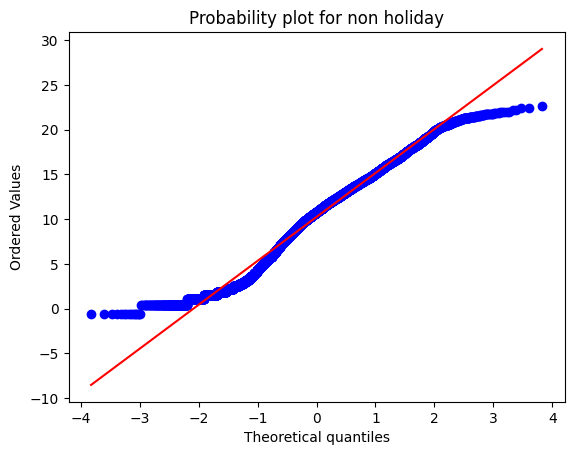

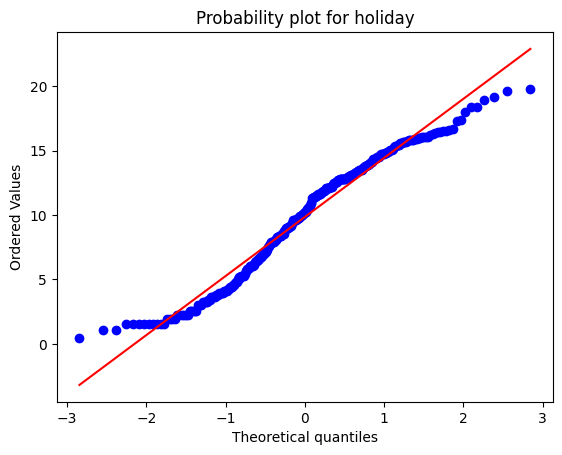

In [ ]:
stats.probplot(df_nhd['rgd'], dist="norm", plot=plt)
plt.title('Probability plot for non holiday')
plt.show()
stats.probplot(df_hd['rgd'], dist="norm", plot=plt)
plt.title('Probability plot for holiday')
plt.show()

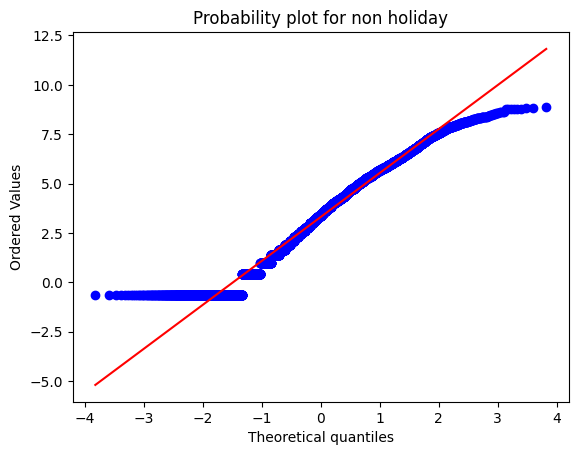

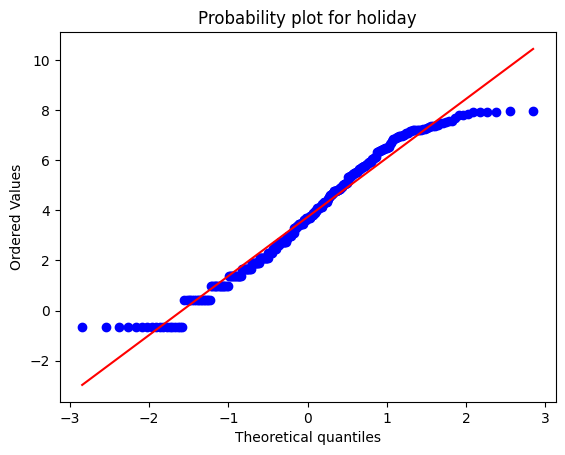

In [ ]:
stats.probplot(df_nhd['csl'], dist="norm", plot=plt)
plt.title('Probability plot for non holiday')
plt.show()
stats.probplot(df_hd['csl'], dist="norm", plot=plt)
plt.title('Probability plot for holiday')
plt.show()

**Is there a significant difference in count of bike rentals on a holiday against a non holiday?**

*Hypothesis test:*

The two populations being compared are:
* number of bike rented on holidays-df_hd['cnt']
* number of bike rented on non holidays-df_nhd['cnt']

Although these are not pure normal distributed, we choose the independent T test; carrying out a 2 tailed test.
* Ho: There is no significant difference in bike hiring on non-holidays days as compared to holidays.
* H1: There is significant difference in bike hiring on non-holidays as compared to holidays.

Level of significance: 0.05

In [ ]:
tval1,pval1=stats.ttest_ind(df_nhd['rgd'], df_hd['rgd'])
print('t-value:', tval1)
print('p-value:', pval1)
if pval1 < 0.025:
  print('The T-test rejects the null hypothesis, bike rentals by registered customers on holidays are significantly different than those on non-holidays.')
else:
  print('The T-test fails to reject the null hypothesis, bike rentals by registered customers on non-holidays are similar to those on holidays.')

t-value: 1.4318308425759132
p-value: 0.15222095333699667
The T-test fails to reject the null hypothesis, bike rentals by registered customers on non-holidays are similar to those on holidays.


In [ ]:
tval1,pval1=stats.ttest_ind( df_hd['csl'], df_nhd['csl'])
print('t-value:', tval1)
print('p-value:', pval1)
if pval1 < 0.025:
  print('The T-test rejects the null hypothesis, bike rentals by casual customers on holidays are significantly different than those on non-holidays.')
else:
  print('The T-test fails to reject the null hypothesis, bike rentals by casual customers on non-holidays are similar to those on holidays.')

t-value: 3.2917519202832595
p-value: 0.0009988249727991257
The T-test rejects the null hypothesis, bike rentals by casual customers on holidays are significantly different than those on non-holidays.


**Question:** Is there a significant difference between bike rentals for different seasons.

The data:

In [ ]:
df_nu.weather.value_counts()

,count
weather,
1,7192
2,2834
3,859
4,1


In [ ]:
lst1

['rgd', 'csl', 'cnt']

In [ ]:
rgdata=[]
for i in range(4):
  rgdata.append(df_nu[df_nu.season==i+1]['rgd'])

In [ ]:
rgde1=df_nu[df_nu.weather==1]['rgd']
rgde2=df_nu[df_nu.weather==2]['rgd']
rgde3=df_nu[df_nu.weather==3]['rgd']
#cnte4=df_nu[df_nu.weather==4]['cnt']

In [ ]:
pg.normality(rgde1), pg.normality(rgde2), pg.normality(rgde3)

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)


(            W          pval  normal
 rgd  0.978076  7.429131e-32   False,
             W          pval  normal
 rgd  0.982155  2.056654e-18   False,
            W          pval  normal
 rgd  0.98502  1.073233e-07   False)

In [ ]:
stats.skew(rgde1), stats.skew(rgde2), stats.skew(rgde3)

(-0.19564295115832286, -0.09624120962174393, 0.23358387358834642)

In [ ]:
fstat, pval=stats.f_oneway(rgde1, rgde2, rgde3)
print('F-statistic:', fstat)
print('p-value:', pval)

F-statistic: 76.5194791716397
p-value: 9.989030711068711e-34


In [ ]:
fstat, pval=stats.f_oneway(csle1, csle2, csle3)
print('F-statistic:', fstat)
print('p-value:', pval)

F-statistic: 140.9136191745073
p-value: 3.810994285907181e-61


In [ ]:
fstat, pval=stats.f_oneway(cnte1, cnte2, cnte3)
print('F-statistic:', fstat)
print('p-value:', pval)

NameError: name 'stats' is not defined

In [ ]:
stats.levene(rgde1, rgde2, rgde3, center='mean')

LeveneResult(statistic=10.20094970775354, pvalue=3.7491394921687275e-05)

In [ ]:
pg.normality(cnte1), pg.normality(cnte2), pg.normality(cnte3)

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)


(            W          pval  normal
 cnt  0.975732  3.006492e-33   False,
             W          pval  normal
 cnt  0.980115  1.708759e-19   False,
             W          pval  normal
 cnt  0.984652  7.772844e-08   False)

In [ ]:
stats.skew(cnte1), stats.skew(cnte2), stats.skew(cnte3)

(-0.22137970584154967, -0.15152501494155543, 0.24719712784335052)

In [ ]:
stats.levene(cnte1, cnte2, cnte3, center='mean')

LeveneResult(statistic=17.281664662528634, pvalue=3.210424125495831e-08)

In [ ]:
stats.skew(csle1), stats.skew(csle2), stats.skew(csle3)

(-0.13525738239764057, -0.057061430607805406, 0.40580799911295257)

In [ ]:
stats.levene(csle1, csle2, csle3, center='mean')

LeveneResult(statistic=24.242249658248657, pvalue=3.1268680386815355e-11)

In [ ]:
stats.skew(cntd1), stats.skew(cntd2), stats.skew(cntd3), stats.skew(cntd4)

(0.04376195313207943,
 -0.2535027483926227,
 -0.35188268854655014,
 -0.25041187753302746)

In [ ]:
stats.levene(cntd1, cntd2, cntd3, cntd4, center='mean')

LeveneResult(statistic=26.98954800267742, pvalue=2.2016889164307197e-17)

In [ ]:
df.duplicated().sum()

0

In [ ]:
fstat, pval=stats.f_oneway(cntd1, cntd2, cntd3, cntd4)
print('F-statistic:', fstat)
print('p-value:', pval)

F-statistic: 228.10883207690665
p-value: 1.5585321447229476e-143


In [ ]:
fstst, pval=stats.f_oneway(rgdata[0], rgdata[1], rgdata[2], rgdata[3])
print('F-statistic:', fstst)
print('p-value:', pval)

In [ ]:
rgdata=pd.DataFrame(rgdata)

In [ ]:
for i in range(4):
  print(pg.normality(rgdata.iloc[i]))

stats.skew(rgdata.iloc[0])


            W          pval  normal
rgd  0.983555  4.225808e-17   False
            W          pval  normal
rgd  0.975872  4.134976e-21   False
           W          pval  normal
rgd  0.97515  2.011099e-21   False
            W          pval  normal
rgd  0.972925  2.374379e-22   False


nan

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
cs1=df_nu[df_nu.season==1]['csl']
cs2=df_nu[df_nu.season==2]['csl']
cs3=df_nu[df_nu.season==3]['csl']
cs4=df_nu[df_nu.season==4]['csl']

Test for normal of the datasets:

In [ ]:
pg.normality(s1), pg.normality(s2), pg.normality(s3), pg.normality(s4)

(            W          pval  normal
 cnt  0.984191  9.903301e-17   False,
             W          pval  normal
 cnt  0.970902  3.864078e-23   False,
             W          pval  normal
 cnt  0.966223  7.944779e-25   False,
             W          pval  normal
 cnt  0.973496  4.044611e-22   False)

In [ ]:
pg.normality(cs1), pg.normality(cs2), pg.normality(cs3), pg.normality(cs4)

(            W          pval  normal
 csl  0.956305  1.151918e-27   False,
             W          pval  normal
 csl  0.975403  2.584439e-21   False,
             W          pval  normal
 csl  0.962082  3.532924e-26   False,
             W          pval  normal
 csl  0.983057  1.483882e-17   False)

The datasets fail test for normalness.

Skewness measure:

In [ ]:
sset=[s1, s2, s3, s4]
for i in range(len(sset)):
  print(stats.skew(sset[i]))

0.04376195313207943
-0.2535027483926227
-0.35188268854655014
-0.25041187753302746


In [ ]:
cset=[cs1, cs2, cs3, cs4]
for i in range(len(cset)):
  print(stats.skew(cset[i]))

0.4313731816721186
-0.3179952327816709
-0.5063960097621348
0.00843147320958305


The datasets are little skewed.

Test for equality of variance of datasets

In [ ]:
stt, pval2=stats.levene(s1, s2, s3, s4, center='mean')
print(stt, pval2)
if pval2 < 0.025:
  print('The Levene test rejects the null hypothesis, variances are not equal.')
else:
  print('The Levene test fails to reject the null hypothesis, variances are equal.')

26.98954800267742 2.2016889164307197e-17
The Levene test rejects the null hypothesis, variances are not equal.


In [ ]:
cstt, pval2c=stats.levene(cs1, cs2, cs3, cs4, center='mean')
print(cstt, pval2c)
if pval2c < 0.025:
  print('The Levene test rejects the null hypothesis, variances are not equal.')
else:
  print('The Levene test fails to reject the null hypothesis, variances are equal.')

17.510563427753507 2.4519416750587926e-11
The Levene test rejects the null hypothesis, variances are not equal.


The variance of datasets are not equal.

Conditions for ANOVA not fulfilled although, we proceed with ANOVA test. The results will be inferred with caution.

In [ ]:
sstat, spval=stats.f_oneway(s1, s2, s3, s4)
print('F-statistic:', sstat)
print('p-value:', spval)

F-statistic: 228.10883207690665
p-value: 1.5585321447229476e-143


In [ ]:
cstat, cspval=stats.f_oneway(cs1, cs2, cs3, cs4)
print('F-statistic:', cstat)
print('p-value:', cspval)

F-statistic: 564.4679680715748
p-value: 0.0


The value of F-statistic is large, and p-value very small. The ineference of test results does not seem to be affected by the requirements of the test not being fulfilled.

One way ANOVA indicates that atleast one of the other 3 datasets is different.

Analyses for different weather conditions affecting bike rentals:

In [ ]:
df_nu.weather.value_counts()

,count
weather,
1,7192
2,2834
3,859
4,1


In [ ]:
w4=df_nu[df_nu.weather==4]['cnt']
w3=df_nu[df_nu.weather==3]['cnt']
w2=df_nu[df_nu.weather==2]['cnt']
w1=df_nu[df_nu.weather==1]['cnt']

Test for normality of w1, . . .

(w4 is a single row in dataset, hence excluded from test for normality.)

In [ ]:
pg.normality(w1), pg.normality(w2), pg.normality(w3)

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)


(            W          pval  normal
 cnt  0.975732  3.006492e-33   False,
             W          pval  normal
 cnt  0.980115  1.708759e-19   False,
             W          pval  normal
 cnt  0.984652  7.772844e-08   False)

- All datasets fail test for normality.

Test for skewness:

In [ ]:
wset=[w1, w2, w3]
for i in range(len(wset)):
  print(stats.skew(wset[i]))

-0.22137970584154967
-0.15152501494155543
0.24719712784335052


Little skewness is observed for the 3 datasets.

Test for equivalence of variance:

In [ ]:
wstt, phi=stats.levene(w1, w2, w3, center='mean')
print(wstt, phi)
if phi < 0.025:
  print('The Levene test rejects the null hypothesis, variances are not equal.')
else:
  print('The Levene test fails to reject the null hypothesis, variances are equal.')

17.281664662528634 3.210424125495831e-08
The Levene test rejects the null hypothesis, variances are not equal.


Though conditions for ANOVA not fulfilled, we proceed with ANOVA test. The results will be inferred with caution.

In [ ]:
fsw, pvsw=stats.f_oneway(w1, w2, w3, w4)
print('F-statistic:', fsw)
print('p-value:', pvsw)

F-statistic: 63.082866175642586
p-value: 1.98361602947039e-40


The F-statistic is large, and p-value is very small. The inference "atleast one of the datasets differ significantly from others" holds.

**Question:** Weather there is significant difference in impact of season v/s weather?

Carrying out chi-squared test on contigency table for 'season'X'weather':

- 'weather'= 4 has only one row, which will preempt the result of chi-squared test, hence we impute that row from the data and then carry out the test.

Contigency table weather v/s season:

In [ ]:
df_nu['season'].value_counts()

,count
season,
4,2734
2,2733
3,2733
1,2686


In [ ]:
df_nu['weather'].value_counts()

,count
weather,
1,7192
2,2834
3,859
4,1


In [ ]:
dfr=df_nu[df_nu['weather']!=4]

CHI-Squared test: To test whether the two categorical columns 'weather' and 'season' are related.
- Ho: The 2 variables are related.
- H1: The 2 variables are unrelated

Level of significance(alpha) = 0.05

In [ ]:
ct=pd.crosstab(dfr['season'], dfr['weather'])
ct

weather,1,2,3
season,,,
1,1759,715,211
2,1801,708,224
3,1930,604,199
4,1702,807,225


In [ ]:
stats.chi2_contingency(ct)

Chi2ContingencyResult(statistic=46.10145731073249, pvalue=2.8260014509929343e-08, dof=6, expected_freq=array([[1774.04869086,  699.06201194,  211.8892972 ],
       [1805.76352779,  711.55920992,  215.67726229],
       [1805.76352779,  711.55920992,  215.67726229],
       [1806.42425356,  711.81956821,  215.75617823]]))

F-statistic is large, and p value observed << 0.05, infering that there exist no significant relationship between cat variables 'weather', and 'season'.

In [ ]:
hw=pd.crosstab(df_nu['holiday'], df_nu['weather'])

In [ ]:
stats.chi2_contingency(hw)

Chi2ContingencyResult(statistic=5.406882723976633, pvalue=0.1443153629276037, dof=3, expected_freq=array([[6.98653316e+03, 2.75303601e+03, 8.34459397e+02, 9.71431196e-01],
       [2.05466838e+02, 8.09639904e+01, 2.45406026e+01, 2.85688040e-02]]))

In [ ]:
stats.chi2_contingency(pd.crosstab(df_nu['season'], df_nu['weather']))

Chi2ContingencyResult(statistic=49.158655596893624, pvalue=1.549925073686492e-07, dof=9, expected_freq=array([[1.77454639e+03, 6.99258130e+02, 2.11948742e+02, 2.46738931e-01],
       [1.80559765e+03, 7.11493845e+02, 2.15657450e+02, 2.51056403e-01],
       [1.80559765e+03, 7.11493845e+02, 2.15657450e+02, 2.51056403e-01],
       [1.80625831e+03, 7.11754180e+02, 2.15736359e+02, 2.51148264e-01]]))

In [ ]:
df_nu.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'atemp',
       'humidity', 'cnt', 'wspd'],
      dtype='object')

In [ ]:
stats.chi2_contingency(pd.crosstab(df_nu['season'], df_nu['holiday']))

Chi2ContingencyResult(statistic=20.82338817816167, pvalue=0.00011455163312609901, dof=3, expected_freq=array([[2609.26419254,   76.73580746],
       [2654.92145875,   78.07854125],
       [2654.92145875,   78.07854125],
       [2655.89288995,   78.10711005]]))

In [ ]:
stats.chi2_contingency(pd.crosstab(df_nua['holiday'], df_nua['workingday']))

Chi2ContingencyResult(statistic=664.4983827767504, pvalue=1.570549156689075e-146, dof=1, expected_freq=array([[3345.71273, 6996.28727],
       [ 100.28727,  209.71273]]))

In [ ]:
stats.f_oneway(df_nua[df_nua.weather==1]['count'], df_nua[df_nua.weather==2]['count'], df_nua[df_nua.weather==3]['count'], df_nua[df_nua.weather==4]['count'])

F_onewayResult(statistic=62.05973884040978, pvalue=9.048124557450182e-40)

In [ ]:
sw=pd.crosstab(df_nua['season'], df_nua['weather'])

In [ ]:
stats.chi2_contingency(sw)

Chi2ContingencyResult(statistic=49.77990834253153, pvalue=1.1849008434345232e-07, dof=9, expected_freq=array([[1.73273395e+03, 6.86991363e+02, 2.01028633e+02, 2.46057078e-01],
       [1.77306083e+03, 7.02980098e+02, 2.05707285e+02, 2.51783703e-01],
       [1.75455013e+03, 6.95641006e+02, 2.03559707e+02, 2.49155088e-01],
       [1.78165509e+03, 7.06387533e+02, 2.06704375e+02, 2.53004131e-01]]))

In [ ]:
cnt,lm=stats.boxcox(df_nua['count'])

0.3343261152623337

In [ ]:
stats.skew(cnt)

-0.17369229047418153

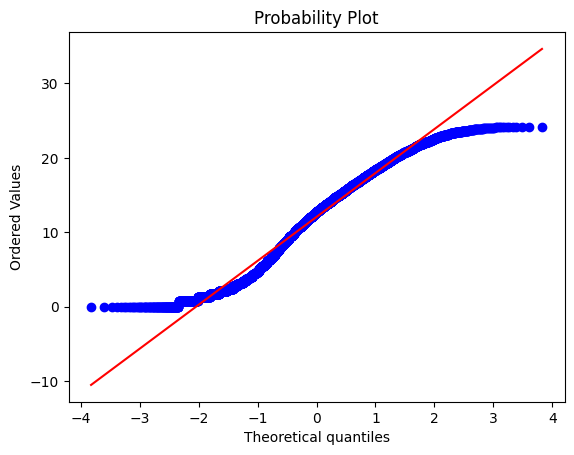

In [ ]:
stats.probplot(cnt, dist="norm", plot=plt)
plt.show()

In [ ]:
cnt,lm=stats.boxcox(df_nua['count'])

In [ ]:
cnt=pd.Series(cnt)

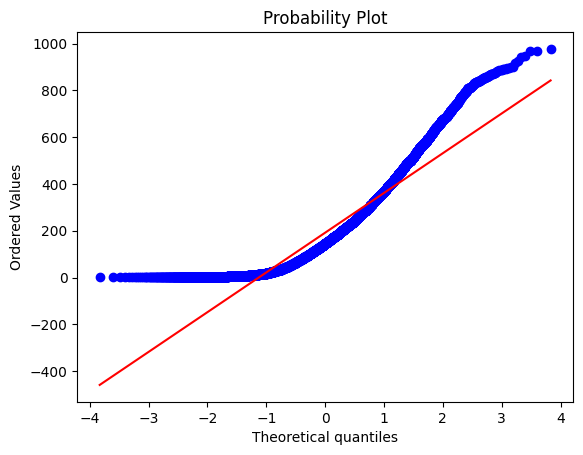

In [ ]:
stats.probplot(df['count'], dist="norm", plot=plt)
plt.show()

In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


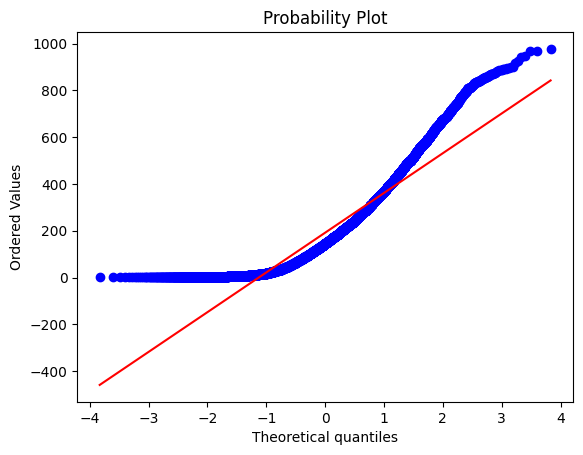

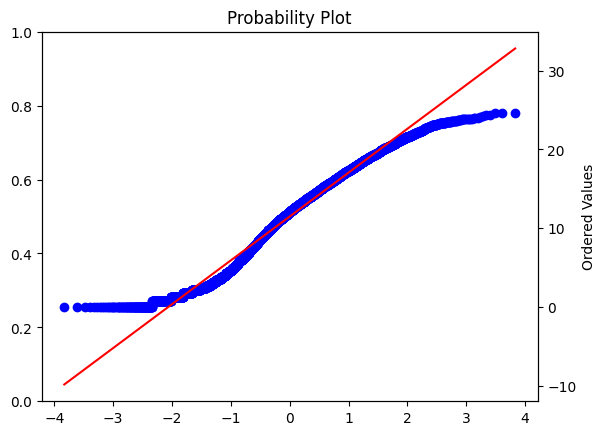

In [ ]:
stats.probplot(df['count'], dist="norm", plot=plt, fit=True)
plt.show()
plt.twinx()
stats.probplot(cnt, dist="norm", plot=plt, fit=True)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
tval, pval = stats.ttest_ind(df['count'], df['temp'])
print("t-value:", tval)
print("p-value:", pval)

t-value: 98.5995199108336
p-value: 0.0


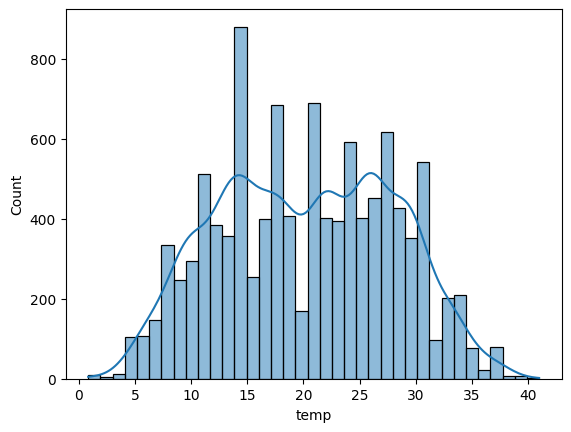

In [ ]:
sns.histplot(df['temp'], kde=True)
plt.show()

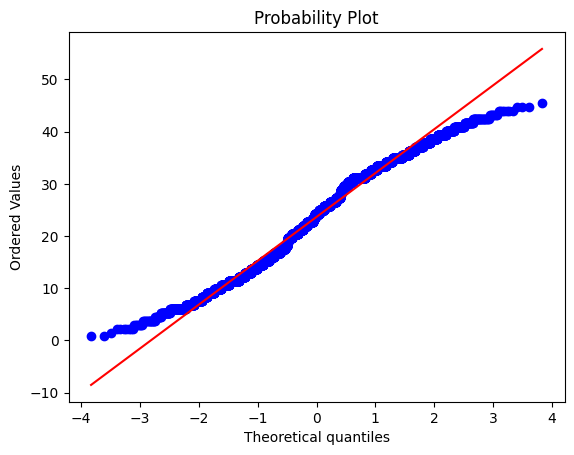

In [ ]:
stats.probplot(df.atemp, dist="norm", plot=plt)
plt.show()

In [ ]:
atem,lmb=stats.boxcox(df['atemp'])

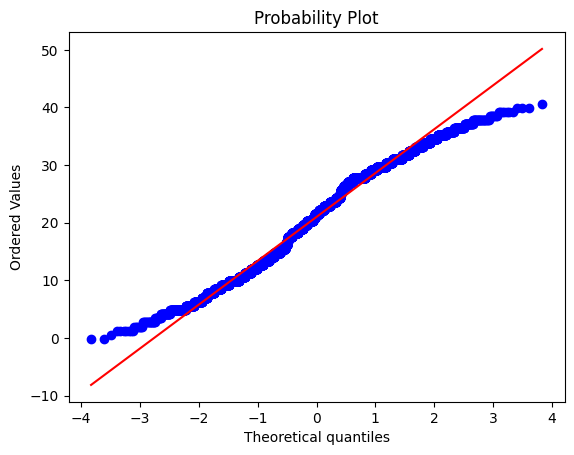

In [ ]:
stats.probplot(atem, dist="norm", plot=plt)
plt.show()

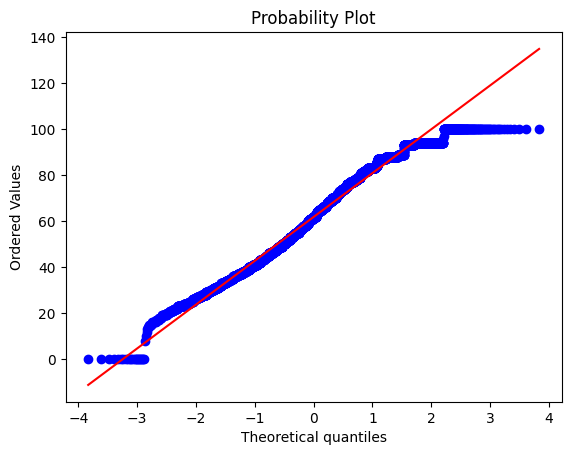

In [ ]:
stats.probplot(df.humidity, dist="norm", plot=plt)
plt.show()

In [ ]:
wns,lmb=stats.boxcox(df['windspeed']+.5)

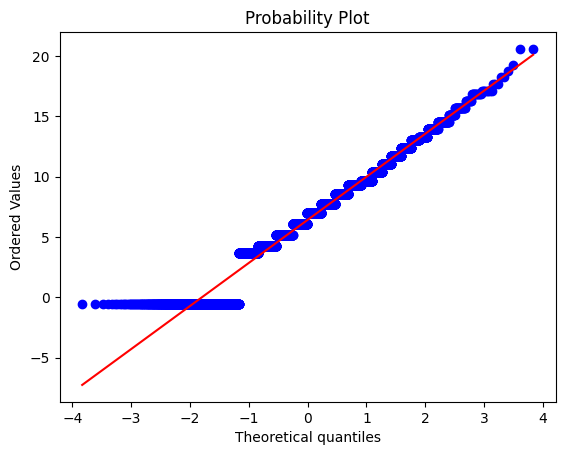

In [ ]:
stats.probplot(wns, dist="norm", plot=plt,fit=True )
plt.show()

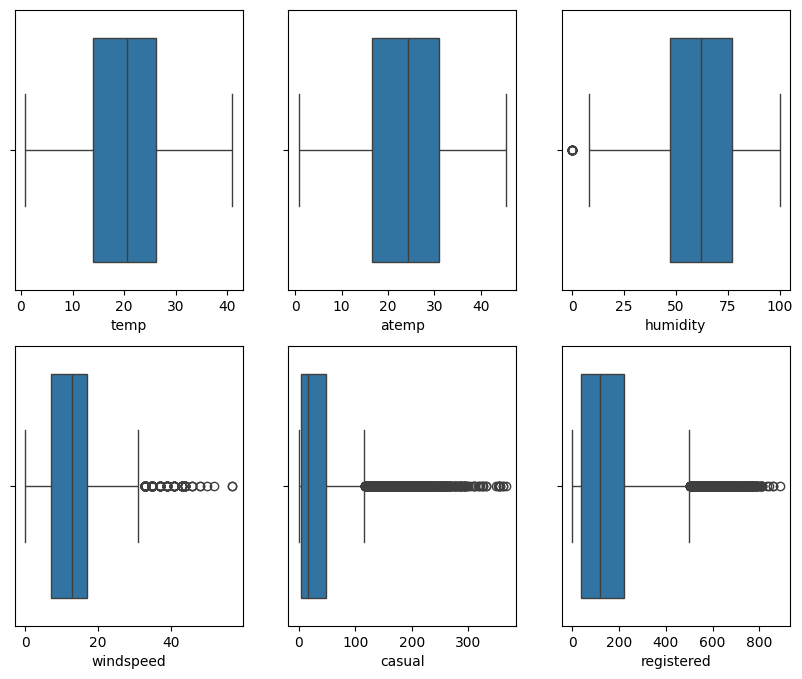

In [ ]:
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))
index = 0
for row in range(2):
    for col in range(3):
        sns.boxplot(x=df[num_cols[index]], ax=axis[row, col])
        index += 1
plt.show()

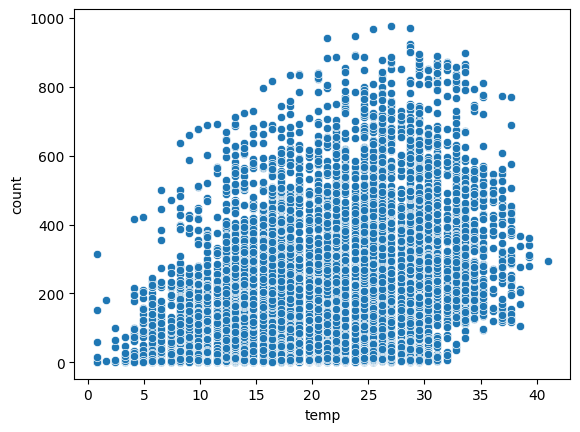

In [ ]:
sns.scatterplot(x='temp', y='count', data=df)
plt.show()

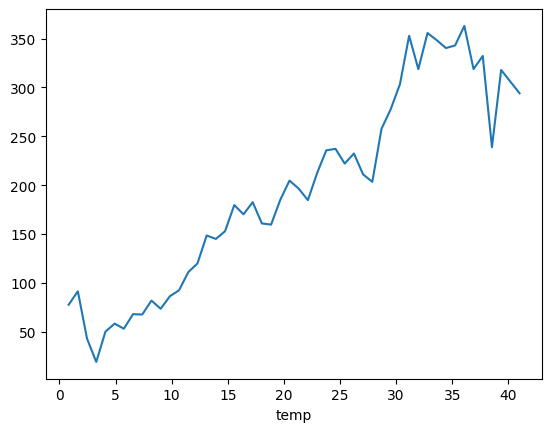

In [ ]:
sns.lineplot(x=df.groupby(by='temp')['count'].mean().index, y=df.groupby(by='temp')['count'].mean().values)
plt.show()

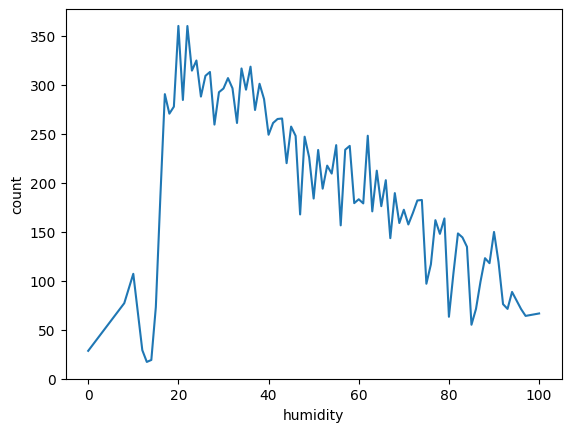

In [ ]:
sns.lineplot(x=df.groupby(by='humidity')['count'].mean().index, y=df.groupby(by='humidity')['count'].mean().values)
plt.xlabel('humidity')
plt.ylabel('count')
plt.show()

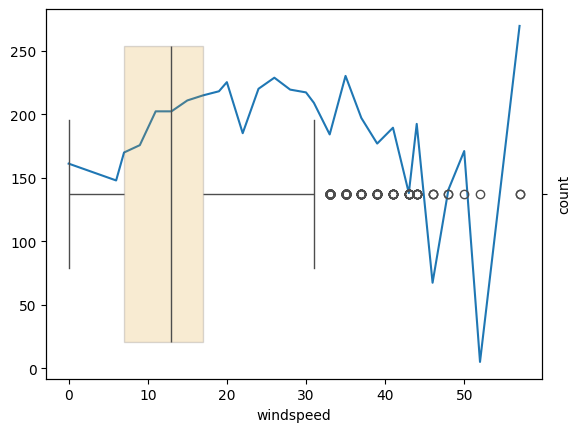

In [ ]:
sns.lineplot(x=df.groupby(by='windspeed')['count'].mean().index, y=df.groupby(by='windspeed')['count'].mean().values)
plt.twinx()
sns.boxplot(x=df.windspeed, boxprops=dict(alpha=.2), color='orange' )
plt.xlabel('windspeed')
plt.ylabel('count')
plt.show()

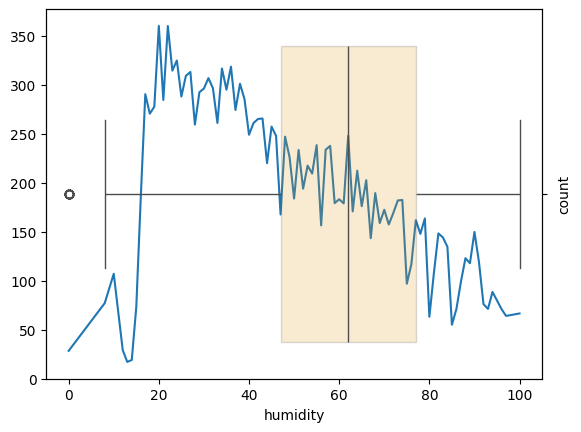

In [ ]:
sns.lineplot(x=df.groupby(by='humidity')['count'].mean().index, y=df.groupby(by='humidity')['count'].mean().values)
plt.twinx()
sns.boxplot(x=df.humidity, boxprops=dict(alpha=.2), color='orange' )
plt.xlabel('humidity')
plt.ylabel('count')
plt.show()

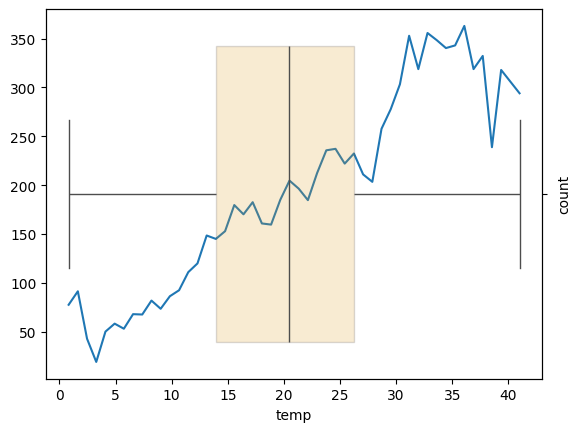

In [ ]:
sns.lineplot(x=df.groupby(by='temp')['count'].mean().index, y=df.groupby(by='temp')['count'].mean().values)
plt.twinx()
sns.boxplot(x=df.temp, boxprops=dict(alpha=.2), color='orange' )
plt.xlabel('temp')
plt.ylabel('count')
plt.show()

KeyError: 'x'

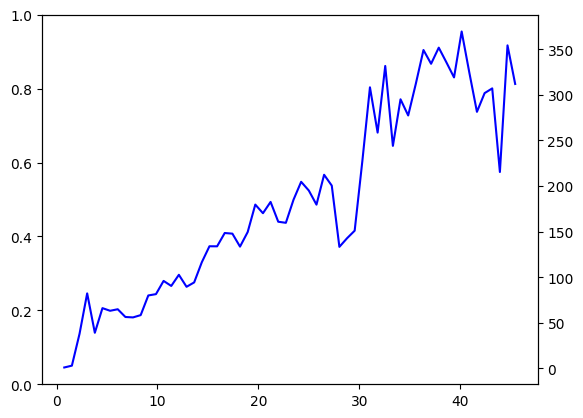

In [ ]:
plt.twinx()
sns.lineplot(x=df.groupby(by='atemp')['count'].mean().index, y=df.groupby(by='atemp')['count'].mean().values, color='blue')
plt.xlabel('temp')
sns.lineplot(x=df.groupby(by='temp')['count'].mean().index, y=df.groupby(by='temp')['count'].mean().values, color='red')
plt.ylabel('count')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  dy_w        10886 non-null  int32         
dtypes: category(4), datetime64[ns](1), float64(3), int32(1), int64(4)
memory usage: 766.2 KB


In [ ]:
data_table = pd.crosstab(df['season'], df['weather'])
print("Observed values:")
data_table

Observed values:


weather,1,2,3,4
season,,,,
1,1759,715,211,1
2,1801,708,224,0
3,1930,604,199,0
4,1702,807,225,0


In [ ]:
val = stats.chi2_contingency(data_table)
val

Chi2ContingencyResult(statistic=20.82338817816167, pvalue=0.00011455163312609901, dof=3, expected_freq=array([[2609.26419254,   76.73580746],
       [2654.92145875,   78.07854125],
       [2654.92145875,   78.07854125],
       [2655.89288995,   78.10711005]]))

In [ ]:
np.percentile(df.temp, 95)

32.8

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
dff=df[(df.temp> np.percentile(df.temp, 5)) & (df.temp< np.percentile(df.atemp, 95))]

In [ ]:
(len(df)-len(dff))/len(df)

0.07449935697225794

In [ ]:
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered']
res=pg.normality(dff[num_cols])
res

NameError: name 'pg' is not defined